## A circle hiding in a square

Imagine a square of side length 1, with a quarter of a unit circle tucked into one corner. The square has area 1; the quarter circle has area π/4.

If we scatter points uniformly across the square, the fraction inside the quarter circle estimates π/4. Multiply that fraction by 4, and we get an estimate of π. A point is inside when x² + y² ≤ 1.

In [1]:
import math
import random

# Keep the seed fixed so this experiment is reproducible.
rng = random.Random(42)
sample_size = 10_000
points = [(rng.random(), rng.random()) for _ in range(sample_size)]
inside = sum(x * x + y * y <= 1 for x, y in points)
estimate = 4 * inside / sample_size
print(f"Points: {sample_size:,}")
print(f"Estimate of pi: {estimate:.6f}")
print(f"Absolute error: {abs(estimate - math.pi):.6f}")

Points: 10,000
Estimate of pi: 3.126000
Absolute error: 0.015593


## Make the experiment visible

Blue points fall inside the quarter circle; orange points fall outside it. The figure shows the first 800 of the 10,000 sampled points so that the pattern stays readable. The estimate above uses every point.

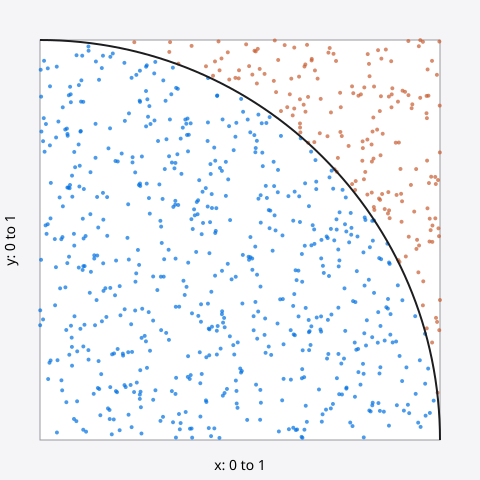

In [2]:
from IPython.display import SVG, display

# Draw the first 800 points using only Python's standard library.
# Blue: inside the quarter circle. Orange: outside.
parts = [
    '<svg xmlns="http://www.w3.org/2000/svg" width="480" height="480" viewBox="0 0 480 480">',
    '<rect width="480" height="480" fill="#f5f5f7"/>',
    '<rect x="40" y="40" width="400" height="400" fill="white" stroke="#9a9aa0"/>',
]
for x, y in points[:800]:
    color = "#0071e3" if x * x + y * y <= 1 else "#c85c31"
    parts.append(
        f'<circle cx="{40 + 400 * x:.2f}" cy="{440 - 400 * y:.2f}" '
        f'r="2" fill="{color}" opacity="0.7"/>'
    )
parts.append(
    '<path d="M 40 40 A 400 400 0 0 1 440 440" fill="none" stroke="#1d1d1f" stroke-width="2"/>'
)
parts.append(
    '<text x="240" y="470" text-anchor="middle" font-family="sans-serif" '
    'font-size="14">x: 0 to 1</text>'
)
parts.append(
    '<text x="15" y="240" text-anchor="middle" font-family="sans-serif" '
    'font-size="14" transform="rotate(-90 15 240)">y: 0 to 1</text>'
)
parts.append("</svg>")
svg = "".join(parts)
display(SVG(svg))

## What changes with more points?

Try a larger sample and compare the absolute error. Randomness means the error can go up at an individual step. Across repeated experiments, the typical error decreases roughly in proportion to 1/√n, so reducing that typical error by half takes about four times as many points.

In [3]:
# A larger sample tends to be more accurate, but not at every step.
for n in (100, 1_000, 10_000, 100_000):
    rng = random.Random(42)
    count = sum(rng.random() ** 2 + rng.random() ** 2 <= 1 for _ in range(n))
    value = 4 * count / n
    print(f"n={n:>7,}   pi≈{value:.5f}   error={abs(value - math.pi):.5f}")

n=    100   pi≈3.12000   error=0.02159
n=  1,000   pi≈3.12800   error=0.01359
n= 10,000   pi≈3.12600   error=0.01559
n=100,000   pi≈3.13728   error=0.00431
